In [1]:
!pip -q install trl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 825.1/825.1 kB 16.8 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 99.7 MB/s eta 0:00:00:00:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompat

In [2]:
import os

import torch
from datasets import load_dataset
from peft import LoraConfig
from transformers import AutoModelForCausalLM, AutoTokenizer
from trl import SFTConfig, SFTTrainer

# --- 1. CONFIGURATION ---
MODEL_ID = "Qwen/Qwen3-1.7B-Base"
# Remplace avec tes vrais chemins sur Kaggle
TRAIN_PATH = "/kaggle/input/datasets/chris36/sft-train-dataset/Mpaga_Christophe_1_Dataset_Train_SFT_052026.jsonl"
VAL_PATH = "/kaggle/input/datasets/chris36/validation-dataset-sft/Mpaga_Christophe_1_Dataset_Val_SFT_052026.jsonl"
OUTPUT_DIR = "/kaggle/working/chsa_qwen3_sft_final"

In [3]:
# --- 2. CHARGEMENT MODÈLE ET TOKENIZER (MODE FP16 SÉCURISÉ) ---
print("📥 Chargement du modèle Qwen3 (Reasoning Model)...")

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

# Chargement en FP16 natif (Correction du bug set_submodule)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID, dtype=torch.float16, device_map="auto", trust_remote_code=True
)

# Désactivation du cache pour le training
model.config.use_cache = False
model.config.pad_token_id = tokenizer.pad_token_id

📥 Chargement du modèle Qwen3 (Reasoning Model)...


config.json:   0%|          | 0.00/727 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/138 [00:00<?, ?B/s]

In [4]:
# --- 3. PRÉPARATION DU DATASET (CHATML) ---
print("📊 Préparation des données bilingues...")


def format_chatml(ex):
    # Format ChatML strict pour Qwen3
    # Note : On peut ajouter des balises <think> si tes données en possèdent
    return {
        "text": f"<|im_start|>system\nTu es l'infirmier d'accueil du CHSA.<|im_end|>\n<|im_start|>user\n{ex['instruction']}<|im_end|>\n<|im_start|>assistant\n{ex['response']}<|im_end|>"
    }


train_ds = load_dataset("json", data_files=TRAIN_PATH, split="train").map(format_chatml)
val_ds = load_dataset("json", data_files=VAL_PATH, split="train").map(format_chatml)

📊 Préparation des données bilingues...


Generating train split: 0 examples [00:00, ? examples/s]

Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

In [5]:
# --- 4. CONFIGURATION LORA (Cibles spécifiques Qwen3) ---
peft_config = LoraConfig(
    r=16,
    lora_alpha=32,
    # On cible tous les modules linéaires pour un meilleur raisonnement
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj",
    ],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
)

In [6]:
# --- 5. CONFIGURATION SFT (TRAINING ARGS) ---
sft_config = SFTConfig(
    output_dir=OUTPUT_DIR,
    num_train_epochs=3,  # 3 époques pour bien ancrer les protocoles
    per_device_train_batch_size=2,  # Ajusté pour 16GB VRAM
    gradient_accumulation_steps=8,  # Batch effectif de 32 (2x8x2 GPUs virtuels)
    learning_rate=1e-4,
    lr_scheduler_type="cosine",  # Décroissance douce
    eval_strategy="epoch",
    eval_steps=50,
    save_strategy="epoch",
    load_best_model_at_end=True,
    # --- STABILITÉ GPU P100 ---
    fp16=True,  # Accélération demi-précision
    bf16=False,  # Non supporté sur P100
    gradient_checkpointing=True,  # Économie massive de VRAM
    # --- PARAMÈTRES TRL ---
    dataset_text_field="text",
    # max_seq_length=1024,              # Augmenté pour laisser de la place au raisonnement
    report_to="none",
)

/tmp/ipykernel_59/3687885391.py:2: FutureWarning: The default `loss_type` will change from `'nll'` to `'chunked_nll'` in TRL 1.7. For standard models this is transparent (same math, lower memory) and no action is needed — you'll get the new default automatically on upgrade. If you use a custom model, check ahead of time that `loss_type='chunked_nll'` runs and yields the same loss as `'nll'`; if it doesn't, pin `loss_type='nll'` to keep the current behavior and please open an issue at https://github.com/huggingface/trl/issues so we can address the edge case.
  sft_config = SFTConfig(


In [7]:
# --- 6. INITIALISATION DU TRAINER ---
trainer = SFTTrainer(
    model=model,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    args=sft_config,
    peft_config=peft_config,
    processing_class=tokenizer,  # Nouvelle norme TRL 0.12+
)

print("⚡ Lancement du Fine-Tuning Qwen3...")
trainer.train()

Adding EOS to train dataset:   0%|          | 0/4000 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/4000 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/500 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/500 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


⚡ Lancement du Fine-Tuning Qwen3...


Epoch,Training Loss,Validation Loss,Entropy,Mean Token Accuracy,Num Tokens
1,1.691175,1.704069,1.701170,0.649585,752499.000000
2,1.603359,1.683146,1.639738,0.653611,1504998.000000
3,1.563938,1.686635,1.601262,0.652883,2257497.000000


TrainOutput(global_step=750, training_loss=1.6316949361165365, metrics={'train_runtime': 4305.6892, 'train_samples_per_second': 2.787, 'train_steps_per_second': 0.174, 'total_flos': 2.754896372084736e+16, 'train_loss': 1.6316949361165365, 'epoch': 3.0})

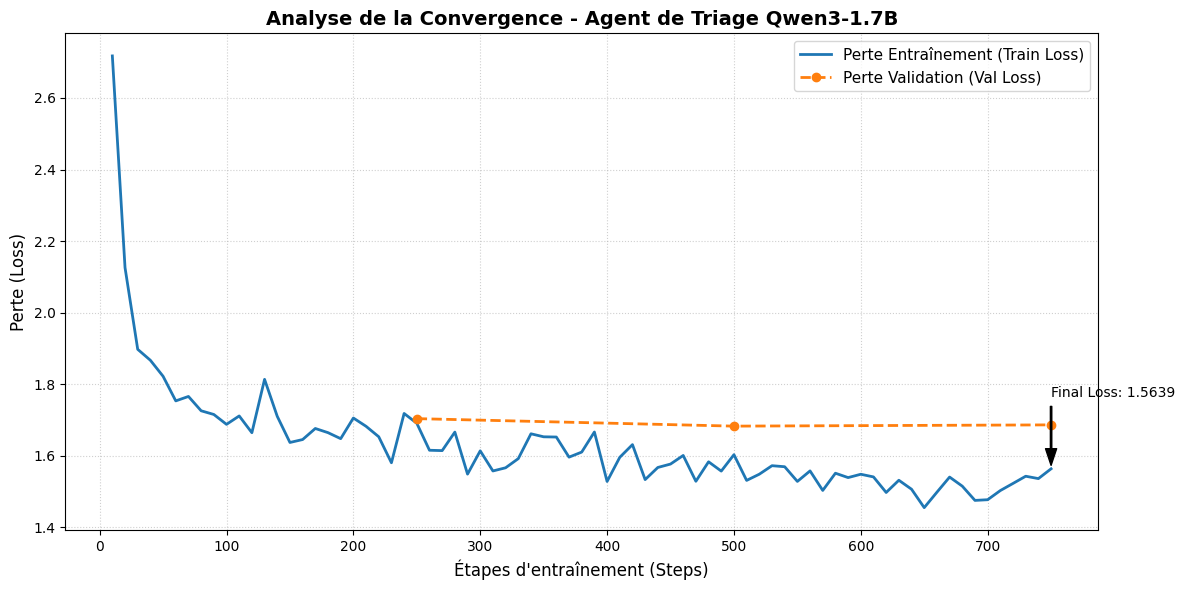

✅ Graphique sauvegardé sous : Mpaga_Christophe_Convergence_SFT_052026.png


In [8]:
import matplotlib.pyplot as plt

# 1. Extraction des données depuis l'historique du trainer
history = trainer.state.log_history

train_loss = []
train_steps = []
val_loss = []
val_steps = []

for entry in history:
    if "loss" in entry:
        train_loss.append(entry["loss"])
        train_steps.append(entry["step"])
    if "eval_loss" in entry:
        val_loss.append(entry["eval_loss"])
        val_steps.append(entry["step"])

# 2. Création du graphique
plt.figure(figsize=(12, 6))

# Courbe d'entraînement
plt.plot(
    train_steps,
    train_loss,
    label="Perte Entraînement (Train Loss)",
    color="#1f77b4",
    linewidth=2,
)

# Courbe de validation (avec des marqueurs pour les points d'évaluation)
if val_loss:
    plt.plot(
        val_steps,
        val_loss,
        label="Perte Validation (Val Loss)",
        color="#ff7f0e",
        marker="o",
        linestyle="--",
        linewidth=2,
    )

# 3. Personnalisation esthétique pour le rapport CHSA
plt.title(
    "Analyse de la Convergence - Agent de Triage Qwen3-1.7B",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Étapes d'entraînement (Steps)", fontsize=12)
plt.ylabel("Perte (Loss)", fontsize=12)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(fontsize=11)

# Ajout d'une annotation pour la perte finale
if train_loss:
    plt.annotate(
        f"Final Loss: {train_loss[-1]:.4f}",
        xy=(train_steps[-1], train_loss[-1]),
        xytext=(train_steps[-1], train_loss[-1] + 0.2),
        arrowprops=dict(facecolor="black", shrink=0.05, width=1, headwidth=8),
    )

# 4. Sauvegarde de l'image pour le livrable 5
plt.tight_layout()
plt.savefig("Mpaga_Christophe_Convergence_SFT_052026.png", dpi=300)
plt.show()

print("✅ Graphique sauvegardé sous : Mpaga_Christophe_Convergence_SFT_052026.png")

In [9]:
# --- 7. SAUVEGARDE FINALE ---
trainer.save_model(OUTPUT_DIR)
print(f"✅ Mission accomplie ! Modèle sauvegardé dans : {OUTPUT_DIR}")

✅ Mission accomplie ! Modèle sauvegardé dans : /kaggle/working/chsa_qwen3_sft_final


In [10]:
import shutil

# 1. Définir le dossier qui contient vos poids entraînés
# (Vérifiez que ce dossier contient adapter_model.safetensors et adapter_config.json)
!mkdir -p /kaggle/working/chsa_model_sft_final
model_folder = "/kaggle/working/chsa_qwen3_sft_final"

# 2. Définir le nom de l'archive (le .zip sera ajouté automatiquement)
archive_name = "Mpaga_Christophe_1_Model_SFT_052026"

# 3. Procédure de compression
if os.path.exists(model_folder):
    print(f"📦 Compression du modèle en cours depuis {model_folder}...")

    # Création du fichier ZIP
    shutil.make_archive(archive_name, "zip", model_folder)

    zip_path = archive_name + ".zip"
    size_gb = os.path.getsize(zip_path) / (1024**3)

    print(f"✅ Archive créée : {zip_path}")
    print(f"📊 Taille : {size_gb:.2f} GB")
    print("\n💡 INSTRUCTIONS DE TÉLÉCHARGEMENT :")
    print(
        "1. Regardez dans le panneau de droite de Kaggle (onglet 'Data' -> 'Output')."
    )
    print("2. Cliquez sur les trois petits points (...) à côté du fichier .zip.")
    print("3. Choisissez 'Download'.")
else:
    print(
        f"❌ Erreur : Le dossier {model_folder} est introuvable. Vérifiez le chemin de sauvegarde de votre trainer."
    )

📦 Compression du modèle en cours depuis /kaggle/working/chsa_qwen3_sft_final...
✅ Archive créée : Mpaga_Christophe_1_Model_SFT_052026.zip
📊 Taille : 0.61 GB

💡 INSTRUCTIONS DE TÉLÉCHARGEMENT :
1. Regardez dans le panneau de droite de Kaggle (onglet 'Data' -> 'Output').
2. Cliquez sur les trois petits points (...) à côté du fichier .zip.
3. Choisissez 'Download'.
